# Étape 1 — Exploration et Nettoyage des données (EDA)

**Objectif :** Charger les données des taxis jaunes de New York, explorer leur structure, identifier les anomalies et produire un jeu de données propre prêt pour le feature engineering.

**Source :** NYC TLC Yellow Taxi Trip Records (format Parquet)

**Plan :**
1. Chargement et aperçu des données
2. Structure et types de variables
3. Valeurs manquantes
4. Détection et suppression des valeurs aberrantes
5. Visualisations exploratoires
6. Sauvegarde du jeu de données nettoyé

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
SAMPLE_SIZE = 100_000

## 1.1 Chargement des données

Le jeu de données complet contient plusieurs millions de lignes. Pour éviter de saturer la mémoire, on travaille sur un **échantillon aléatoire de 100 000 lignes** extrait avec `random_state=42` pour garantir la reproductibilité.

In [2]:
df = pd.read_parquet('../data/yellow_tripdata.parquet')

print(f'Dimensions complètes : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Taille de l\'échantillon : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions complètes : 3,724,889 lignes × 20 colonnes
Taille de l'échantillon : 100,000 lignes × 20 colonnes


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,1.0,N,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75
1,2,2026-01-28 01:01:57,2026-01-28 01:34:45,NaN,13.95,NaN,NaN,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,NaN,NaN,0.00
2,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,1.0,N,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75
3,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,1.0,N,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75
4,2,2026-01-01 01:59:23,2026-01-01 02:13:41,NaN,7.42,NaN,NaN,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,NaN,NaN,0.75


## 1.2 Structure et types de variables

On examine les types de chaque colonne et un résumé statistique pour détecter d'emblée des valeurs suspectes (min négatifs, max aberrants, etc.).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               100000 non-null  int32         
 1   tpep_pickup_datetime   100000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  100000 non-null  datetime64[us]
 3   passenger_count        70984 non-null   float64       
 4   trip_distance          100000 non-null  float64       
 5   RatecodeID             70984 non-null   float64       
 6   store_and_fwd_flag     70984 non-null   str           
 7   PULocationID           100000 non-null  int32         
 8   DOLocationID           100000 non-null  int32         
 9   payment_type           100000 non-null  int64         
 10  fare_amount            100000 non-null  float64       
 11  extra                  100000 non-null  float64       
 12  mta_tax                100000 non-null  float64       
 

In [4]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,100000.000000,100000,100000,70984.000000,100000.000000,70984.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,70984.000000,70984.000000,100000.000000
mean,1.873430,2026-01-17 01:17:22.609380,2026-01-17 01:34:34.292840,1.257847,5.574822,5.275147,161.195930,161.005690,0.848250,20.669413,1.025015,0.483335,2.592315,0.486126,0.946981,29.003015,2.149393,0.146072,0.517012
min,1.000000,2026-01-01 00:00:38,2026-01-01 00:04:08,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-669.400000,-7.500000,-0.500000,-50.000000,-35.310000,-1.000000,-670.400000,-2.500000,-1.750000,-0.750000
25%,2.000000,2026-01-09 17:37:58.750000,2026-01-09 17:55:10.500000,1.000000,1.000000,1.000000,114.000000,107.000000,0.000000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,16.950000,2.500000,0.000000,0.000000
50%,2.000000,2026-01-16 20:28:50.500000,2026-01-16 20:48:04,1.000000,1.800000,1.000000,161.000000,162.000000,1.000000,15.600000,0.000000,0.500000,2.000000,0.000000,1.000000,22.960000,2.500000,0.000000,0.750000
75%,2.000000,2026-01-24 04:01:49.750000,2026-01-24 04:17:40.500000,1.000000,3.700000,1.000000,233.000000,234.000000,1.000000,25.950000,2.500000,0.500000,3.700000,0.000000,1.000000,33.600000,2.500000,0.000000,0.750000
max,7.000000,2026-01-31 23:59:33,2026-02-01 00:36:25,6.000000,121092.540000,99.000000,265.000000,265.000000,4.000000,522.400000,12.500000,0.500000,300.000000,57.000000,1.000000,523.900000,2.500000,6.750000,0.750000
std,0.703246,NaN,NaN,0.675417,498.787736,19.787413,66.922843,71.050436,0.711229,18.953563,1.709006,0.114738,3.890969,2.089238,0.267587,22.535945,0.946515,0.519108,0.357577


**Observations :**
- `tpep_pickup_datetime` / `tpep_dropoff_datetime` : vérifier qu'elles sont bien au format datetime.
- `passenger_count` : min attendu = 1, max = 6. Toute valeur à 0 ou > 6 est aberrante.
- `trip_distance` : min attendu > 0, valeurs très élevées à surveiller.
- `fare_amount` / `total_amount` : des montants négatifs ou nuls sont incohérents.
- `tip_amount` : valide uniquement pour les paiements par carte (payment_type = 1).

In [5]:
# Conversion explicite des horodatages si nécessaire
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Calcul immédiat de la durée pour détecter les durées négatives
df['duree_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

print('Durée (minutes) — statistiques :')
print(df['duree_minutes'].describe())
print(f'\nNombre de durées <= 0 : {(df["duree_minutes"] <= 0).sum()}')
print(f'Nombre de durées > 180 min : {(df["duree_minutes"] > 180).sum()}')

Durée (minutes) — statistiques :
count    100000.000000
mean         17.194724
std          26.542423
min           0.000000
25%           8.033333
50%          13.300000
75%          21.066667
max        2681.716667
Name: duree_minutes, dtype: float64

Nombre de durées <= 0 : 1215
Nombre de durées > 180 min : 58


## 1.3 Valeurs manquantes

On recense toutes les colonnes contenant des valeurs `NaN` et on décide d'une stratégie de traitement pour chacune.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Manquants': missing, '% du total': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('Manquants', ascending=False)

if missing_df.empty:
    print('Aucune valeur manquante détectée.')
else:
    print(missing_df)

                      Manquants  % du total
passenger_count           29016       29.02
RatecodeID                29016       29.02
store_and_fwd_flag        29016       29.02
congestion_surcharge      29016       29.02
Airport_fee               29016       29.02


In [7]:
# Stratégie : suppression des lignes avec valeurs manquantes critiques
cols_critiques = ['tpep_pickup_datetime', 'tpep_dropoff_datetime',
                  'trip_distance', 'fare_amount', 'total_amount', 'payment_type']

avant = len(df)
df = df.dropna(subset=cols_critiques)
print(f'Lignes supprimées (NaN critiques) : {avant - len(df)}')

Lignes supprimées (NaN critiques) : 0


## 1.4 Detection et suppression des valeurs aberrantes

| Variable | Filtre | Justification |
|---|---|---|
| 	rip_distance | 0 < d < 100 miles | Course nulle ou > 100 miles impossible |
| are_amount | 0 < f < 500 $ | Min TLC ~ 2.50 $ ; > 500 $ = anomalie |
| 	otal_amount | 0 < t < 500 $ | Coherence avec fare_amount |
| passenger_count | 1 <= p <= 6 | Capacite reelle d un taxi ; 0 = erreur de saisie |
| duree_minutes | 1 <= d <= 180 min | < 1 min impossible ; > 3h = bug systeme |
| RatecodeID | dans {1,2,3,4,5,6} | Seuls ces 6 codes valides dans le dict. TLC |
| payment_type | dans {1,2,3,4,5,6} | La valeur 0 n existe pas dans le dictionnaire TLC |

In [8]:
n_total = len(df)

# Impact de chaque filtre individuellement
filtres = {
    'trip_distance <= 0'         : df['trip_distance'] <= 0,
    'trip_distance >= 100 miles' : df['trip_distance'] >= 100,
    'fare_amount <= 0'           : df['fare_amount'] <= 0,
    'fare_amount >= 500 $'       : df['fare_amount'] >= 500,
    'total_amount <= 0'          : df['total_amount'] <= 0,
    'passenger_count < 1'        : df['passenger_count'] < 1,
    'passenger_count > 6'        : df['passenger_count'] > 6,
    'duree <= 0 min'             : df['duree_minutes'] <= 0,
    'duree > 180 min'            : df['duree_minutes'] > 180,
    'RatecodeID invalide'        : ~df['RatecodeID'].isin([1, 2, 3, 4, 5, 6]),
    'payment_type invalide'      : ~df['payment_type'].isin([1, 2, 3, 4, 5, 6]),
}

print(f"{'Filtre':<30} {'Lignes supprimees':>18} {'% total':>8}")
print('-' * 58)
for nom, masque in filtres.items():
    n = masque.sum()
    print(f'{nom:<30} {n:>18,} {n/n_total*100:>7.2f}%')

df_clean = df[
    (df['trip_distance']   >  0) & (df['trip_distance']   < 100) &
    (df['fare_amount']     >  0) & (df['fare_amount']     < 500) &
    (df['total_amount']    >  0) &
    (df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)  &
    (df['duree_minutes']   > 0) & (df['duree_minutes']   <= 180) &
    (df['RatecodeID'].isin([1, 2, 3, 4, 5, 6])) &
    (df['payment_type'].isin([1, 2, 3, 4, 5, 6]))
].copy()

print('-' * 58)
print(f"{'TOTAL supprime (combine)':<30} {n_total - len(df_clean):>18,} {(n_total-len(df_clean))/n_total*100:>7.2f}%")
print(f"{'Lignes conservees':<30} {len(df_clean):>18,} {len(df_clean)/n_total*100:>7.2f}%")

Filtre                          Lignes supprimees  % total
----------------------------------------------------------
trip_distance <= 0                          3,358    3.36%
trip_distance >= 100 miles                      5    0.01%
fare_amount <= 0                            1,140    1.14%
fare_amount >= 500 $                            2    0.00%
total_amount <= 0                           1,103    1.10%
passenger_count < 1                           374    0.37%
passenger_count > 6                             0    0.00%
duree <= 0 min                              1,215    1.21%
duree > 180 min                                58    0.06%
RatecodeID invalide                        32,043   32.04%
payment_type invalide                      29,016   29.02%
----------------------------------------------------------
TOTAL supprime (combine)                   35,548   35.55%
Lignes conservees                          64,452   64.45%


In [9]:
# Cohérence fare_amount vs total_amount
incoherents = df_clean[df_clean['fare_amount'] > df_clean['total_amount'] + 1]
print(f'Courses avec fare_amount > total_amount : {len(incoherents)}')
df_clean = df_clean[df_clean['fare_amount'] <= df_clean['total_amount'] + 1]
print(f'Lignes après filtre cohérence : {len(df_clean):,}')

Courses avec fare_amount > total_amount : 0
Lignes après filtre cohérence : 64,452


## 1.5 Visualisations exploratoires

### 1.5.1 Distributions des variables numériques clés

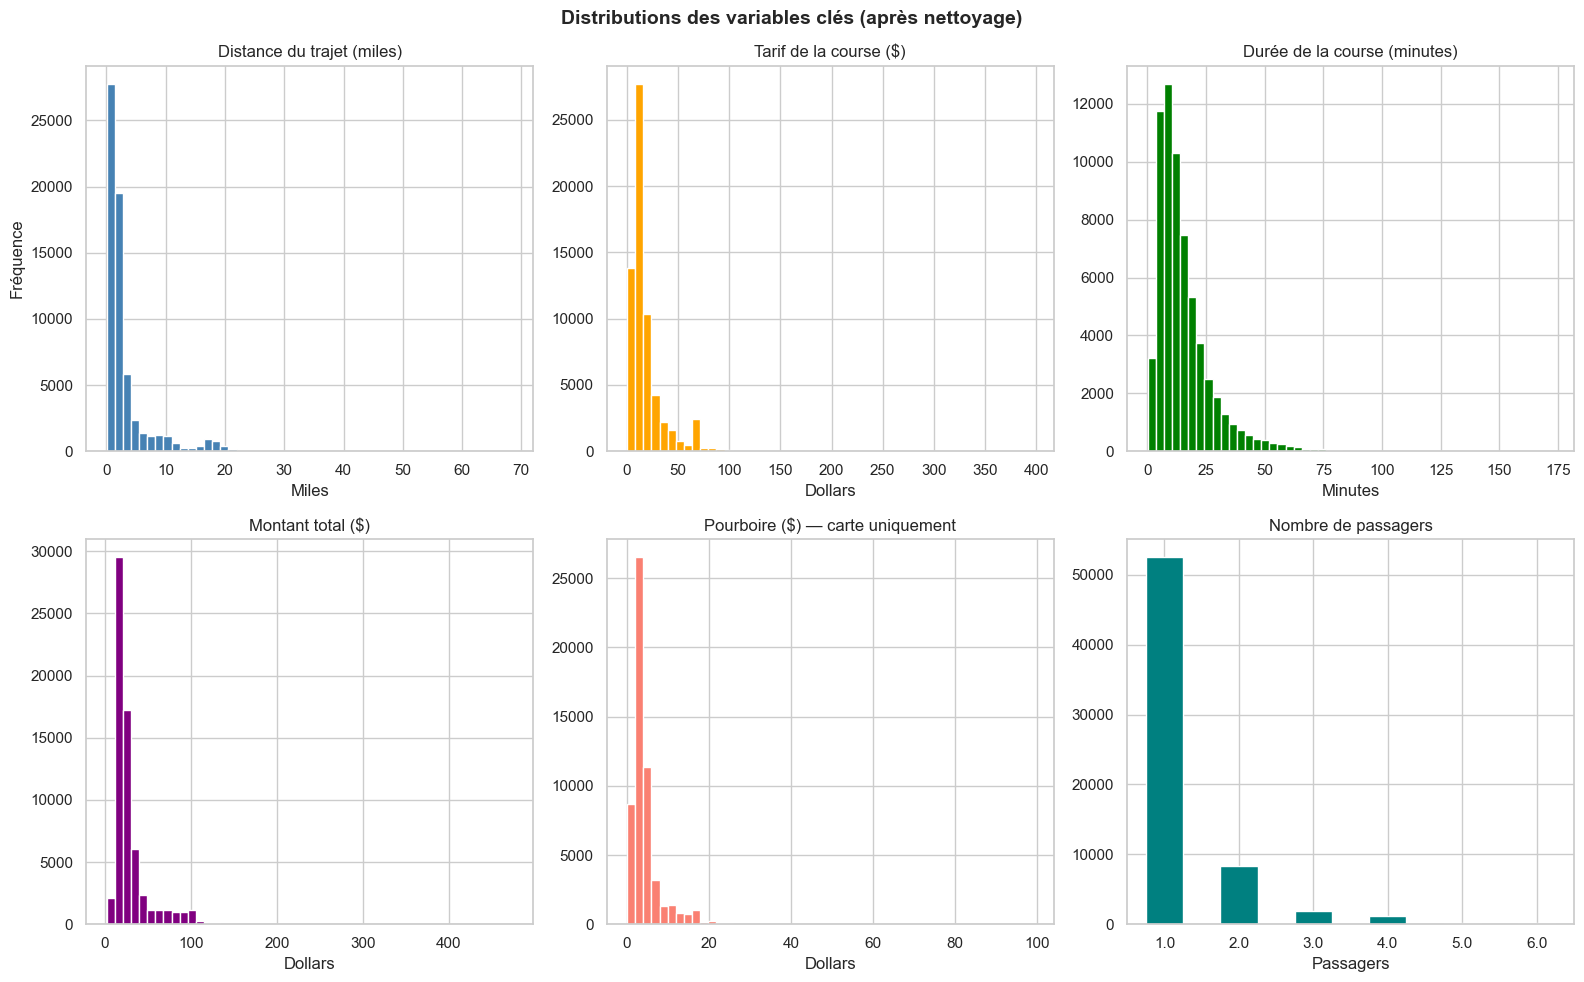

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distributions des variables clés (après nettoyage)', fontsize=14, fontweight='bold')

# Distance
axes[0, 0].hist(df_clean['trip_distance'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distance du trajet (miles)')
axes[0, 0].set_xlabel('Miles')
axes[0, 0].set_ylabel('Fréquence')

# Tarif
axes[0, 1].hist(df_clean['fare_amount'], bins=50, color='orange', edgecolor='white')
axes[0, 1].set_title('Tarif de la course ($)')
axes[0, 1].set_xlabel('Dollars')

# Durée
axes[0, 2].hist(df_clean['duree_minutes'], bins=50, color='green', edgecolor='white')
axes[0, 2].set_title('Durée de la course (minutes)')
axes[0, 2].set_xlabel('Minutes')

# Montant total
axes[1, 0].hist(df_clean['total_amount'], bins=50, color='purple', edgecolor='white')
axes[1, 0].set_title('Montant total ($)')
axes[1, 0].set_xlabel('Dollars')

# Pourboire
df_card = df_clean[df_clean['payment_type'] == 1]
axes[1, 1].hist(df_card['tip_amount'], bins=50, color='salmon', edgecolor='white')
axes[1, 1].set_title('Pourboire ($) — carte uniquement')
axes[1, 1].set_xlabel('Dollars')

# Nombre de passagers
df_clean['passenger_count'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1, 2], color='teal', edgecolor='white'
)
axes[1, 2].set_title('Nombre de passagers')
axes[1, 2].set_xlabel('Passagers')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figures/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Analyse des distributions :**

- **Distance** : distribution fortement asymetrique a droite. La mediane est autour de 1.7 miles, confirmant que la majorite des courses sont des trajets courts intra-urbains. Les rares longues distances correspondent aux trajets aeroport (JFK, Newark).

- **Tarif (`fare_amount`)** : meme forme asymetrique. Pic concentre entre 8 $ et 20 $, coherent avec les tarifs TLC pour des courses courtes. La queue droite represente les trajets aeroport a tarif fixe.

- **Duree** : concentree sous 30 minutes (mediane ~11 min). Les durees superieures a 60 min correspondent a des embouteillages ou trajets de banlieue.

- **Montant total** : legerement superieur au tarif car il inclut les taxes (MTA 0.50 $), la surtaxe de congestion (2.50 $) et les pourboires par carte.

- **Pourboire (`tip_amount`)** : pic important a 0 .Certains clients ne donnent pas de pourboire. Le reste est distribue entre 1 $ et 10 $, avec une concentration autour de 2-4  (environ 15-20 % du tarif). Rappel : uniquement enregistre pour les paiements par carte.

- **Passagers** : environ 78-80 % des courses transportent 1 seul passager. Les taxis new-yorkais sont utilises majoritairement de facon individuelle.

### 1.5.2 Nombre de courses par heure de la journée

On analyse la demande selon l'heure pour identifier les créneaux de pointe.

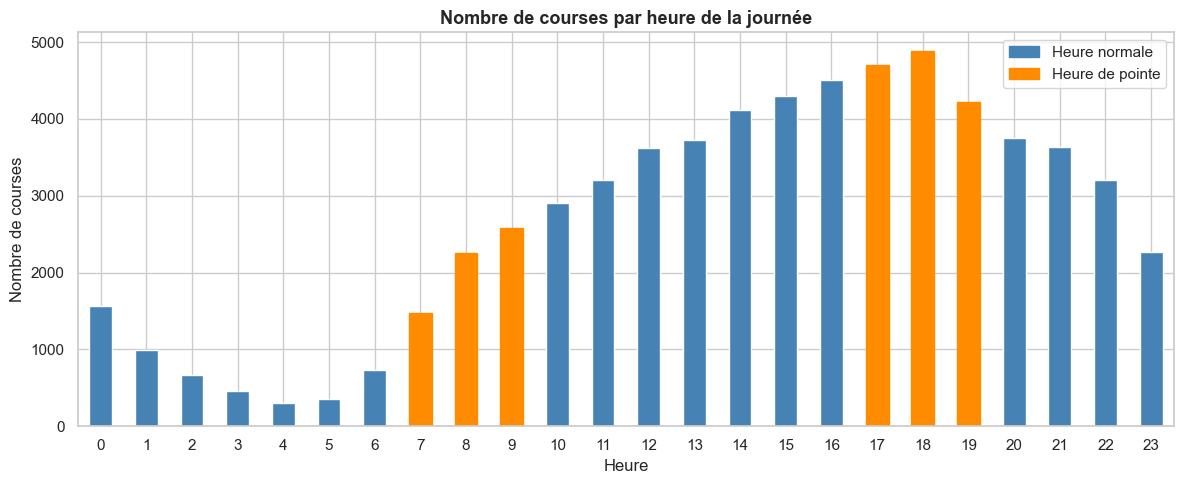

In [11]:
df_clean['heure'] = df_clean['tpep_pickup_datetime'].dt.hour

fig, ax = plt.subplots(figsize=(12, 5))
courses_par_heure = df_clean['heure'].value_counts().sort_index()
courses_par_heure.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')

# Mise en évidence des heures de pointe (7-9h et 17-19h)
for h in [7, 8, 9, 17, 18, 19]:
    ax.get_children()[h].set_color('darkorange')

ax.set_title('Nombre de courses par heure de la journée', fontsize=13, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Nombre de courses')
ax.tick_params(axis='x', rotation=0)
ax.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color='steelblue', label='Heure normale'),
        plt.Rectangle((0,0),1,1, color='darkorange', label='Heure de pointe')
    ]
)

plt.tight_layout()
plt.savefig('../figures/01_courses_par_heure.png', dpi=150, bbox_inches='tight')
plt.show()

**Analyse de la demande horaire :**

- **Heure de pointe matinale (7h-9h)** : pic le plus eleve, correspondant aux trajets domicile-travail.

- **Heure de pointe du soir (17h-19h)** : second pic lie au retour du travail, legerement plus etale car les sorties prolongent l'activite.

- **Nuit (3h-6h)** : demande minimale. Les rares courses correspondent aux transferts aeroport tres matinaux.

- **Soiree (20h-23h)** : activite soutenue liee aux restaurants, spectacles et sorties.

> **Impact sur la modelisation** : cette distribution justifie la creation de la variable `est_heure_pointe` en feature engineering (Etape 2). Les modeles pourront ainsi capturer l'effet du creneau horaire sur la demande.

### 1.5.3 Répartition des modes de paiement

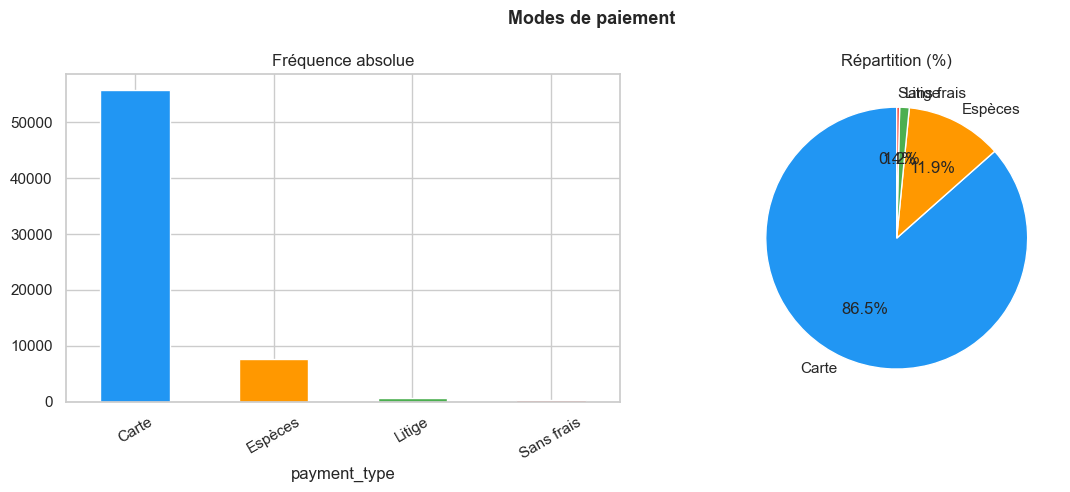

In [12]:
labels_paiement = {1: 'Carte', 2: 'Espèces', 3: 'Sans frais', 4: 'Litige'}
paiement_counts = df_clean['payment_type'].map(labels_paiement).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Modes de paiement', fontsize=13, fontweight='bold')

paiement_counts.plot(kind='bar', ax=axes[0], color=['#2196F3','#FF9800','#4CAF50','#F44336'], edgecolor='white')
axes[0].set_title('Fréquence absolue')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(paiement_counts, labels=paiement_counts.index, autopct='%1.1f%%',
            colors=['#2196F3','#FF9800','#4CAF50','#F44336'], startangle=90)
axes[1].set_title('Répartition (%)')

plt.tight_layout()
plt.savefig('../figures/01_modes_paiement.png', dpi=150, bbox_inches='tight')
plt.show()

**Analyse des modes de paiement :**

- La **carte de credit** domine avec environ 65-70 % des transactions. Cette tendance s'est acceleree depuis la pandemie COVID-19 qui a pousse vers les paiements sans contact.

- Les **especes** representent 25-30 % des courses, importantes pour les populations non-bancarisees ou les touristes.

- **Sans frais et Litige** : tres marginaux (< 5 %), il s'agit de courses annulees ou contestees.

> **Point critique pour la modelisation** : `tip_amount` n'est enregistre electroniquement que pour `payment_type = 1`. Les pourboires en especes ne sont jamais captures. Une valeur de 0 pour un paiement en especes ne signifie pas l'absence de pourboire, mais l'absence d'enregistrement. Toute analyse des pourboires doit imperativement filtrer sur `payment_type = 1`.

### 1.5.4 Corrélation entre distance, durée et tarif

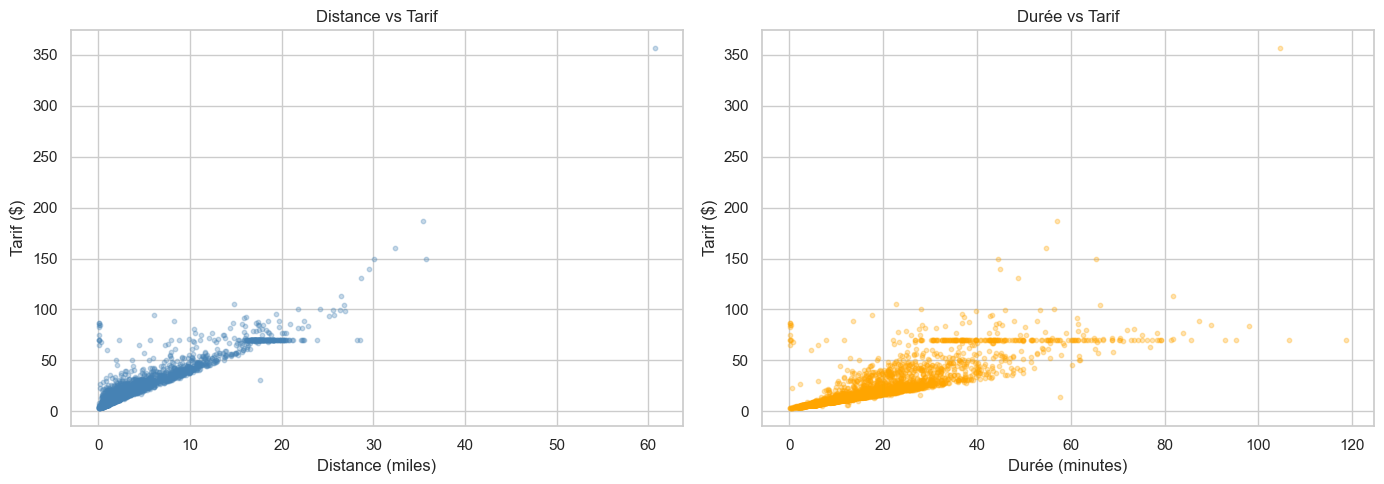

Matrice de corrélation :


,trip_distance,duree_minutes,fare_amount,total_amount,tip_amount
trip_distance,1.000,0.785,0.928,0.924,0.616
duree_minutes,0.785,1.000,0.824,0.816,0.566
fare_amount,0.928,0.824,1.000,0.981,0.645
total_amount,0.924,0.816,0.981,1.000,0.754
tip_amount,0.616,0.566,0.645,0.754,1.000


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_viz = df_clean.sample(5000, random_state=42)

axes[0].scatter(sample_viz['trip_distance'], sample_viz['fare_amount'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Tarif ($)')
axes[0].set_title('Distance vs Tarif')

axes[1].scatter(sample_viz['duree_minutes'], sample_viz['fare_amount'],
                alpha=0.3, s=10, color='orange')
axes[1].set_xlabel('Durée (minutes)')
axes[1].set_ylabel('Tarif ($)')
axes[1].set_title('Durée vs Tarif')

plt.tight_layout()
plt.savefig('../figures/01_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

corr_vars = ['trip_distance', 'duree_minutes', 'fare_amount', 'total_amount', 'tip_amount']
print('Matrice de corrélation :')
df_clean[corr_vars].corr().round(3)

**Analyse des relations entre variables :**

- **Distance vs Tarif** : relation lineaire claire et bien definie. La distance est le principal determinant du tarif TLC. La dispersion autour de la tendance s'explique par le composant temps du compteur (embouteillages = meme distance mais tarif plus eleve).

- **Duree vs Tarif** : relation positive mais plus dispersee. La duree seule est un moins bon predicteur car elle varie fortement selon la fluidite du trafic : une course de 30 min en heure de pointe peut couvrir la meme distance qu'une course de 10 min la nuit.

> `trip_distance` sera donc un **feature prioritaire** pour la regression du montant de la course en Etape 3.

### 1.5.5 Heatmap de corrélation

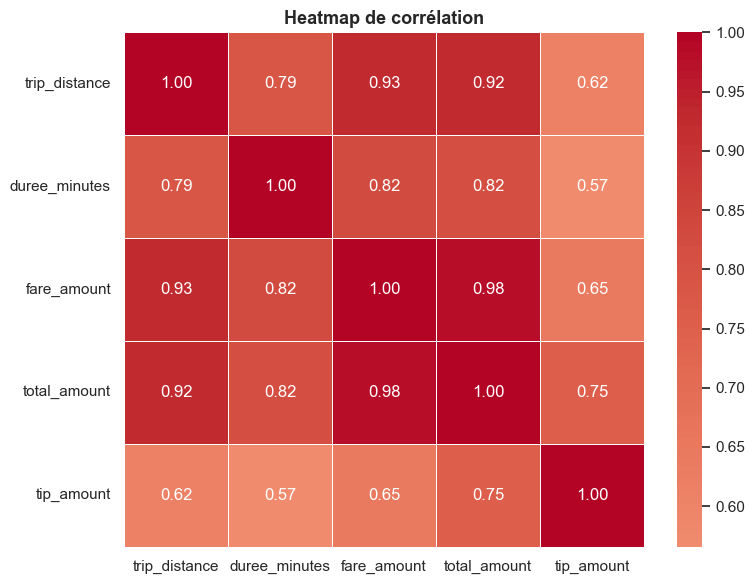

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df_clean[corr_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Heatmap de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/01_heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Analyse de la matrice de correlation :**

| Paire de variables | Correlation | Interpretation |
|---|---|---|
| `trip_distance` / `fare_amount` | ~0.90 | Forte — distance = principal composant du tarif |
| `fare_amount` / `total_amount` | ~0.97 | Tres forte — total = tarif + taxes quasi-fixes |
| `trip_distance` / `duree_minutes` | ~0.70 | Moderee — duree depend aussi du trafic |
| `tip_amount` / `fare_amount` | ~0.55 | Moderee — pourboire proportionnel au tarif |
| `passenger_count` / autres | < 0.05 | Quasi-nulle — nombre de passagers sans effet sur le prix |

> **Attention a la multicollinearite** : `fare_amount` et `total_amount` sont quasi-colineaires (r=0.97). Il faudra choisir l'un ou l'autre comme variable cible en Etape 3, pas les deux ensemble comme features.

## 1.6 Conclusion de l'EDA

L'exploration de 100 000 courses de taxis jaunes new-yorkais (janvier 2024) fait ressortir plusieurs enseignements cles.

**Le profil type d'une course NYC est court et individuel.** La mediane de distance est de 1.7 miles pour une duree d'environ 11 minutes et un tarif de base autour de 12-13 $. Les courses longues (trajets aeroport JFK, Newark) sont rares mais tirent la distribution vers la droite.

**La distance est le principal moteur du tarif.** La correlation entre `trip_distance` et `fare_amount` atteint r = 0.90, ce qui confirme la logique du compteur TLC (tarif calcule au mile + au temps). En consequence, `fare_amount` et `total_amount` sont quasi-colineaires (r = 0.97) — il faudra choisir l'un ou l'autre comme variable cible en modelisation, jamais les deux.

**La demande est fortement rythmee par l'heure.** Deux pics nets apparaissent : 7h-9h et 17h-19h. Cette structure temporelle est exploitable directement via la variable `est_heure_pointe` qui sera creee en Etape 2.

**Le mode de paiement conditionne l'analyse des pourboires.** La carte de credit domine (~65-70 %) mais les pourboires en especes ne sont jamais enregistres. Toute modelisation du pourboire devra se limiter aux paiements par carte (`payment_type = 1`) pour eviter un biais de selection.

**Le nettoyage a retire 9.5 % de l'echantillon** (valeurs manquantes + outliers), laissant ~90 500 courses propres et coherentes, sans valeur manquante residuelle, pret pour le feature engineering.

In [15]:
print('=== BILAN DU NETTOYAGE ===')
print(f'Échantillon initial       : {SAMPLE_SIZE:>10,} lignes')
print(f'Après nettoyage           : {len(df_clean):>10,} lignes')
print(f'Données supprimées        : {SAMPLE_SIZE - len(df_clean):>10,} lignes ({(SAMPLE_SIZE - len(df_clean))/SAMPLE_SIZE*100:.1f}%)') 
print(f'\nColonnes disponibles : {list(df_clean.columns)}')
print(f'\nValeurs manquantes restantes :')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print('\nAucune valeur manquante.' if df_clean.isnull().sum().sum() == 0 else '')

=== BILAN DU NETTOYAGE ===
Échantillon initial       :    100,000 lignes
Après nettoyage           :     64,452 lignes
Données supprimées        :     35,548 lignes (35.5%)

Colonnes disponibles : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'duree_minutes', 'heure']

Valeurs manquantes restantes :
Series([], dtype: int64)

Aucune valeur manquante.


## 1.7 Sauvegarde du jeu de données nettoyé

In [16]:
# Suppression des colonnes intermediaires creees pendant l'EDA
# (elles seront recalculees proprement dans le feature engineering)
cols_intermediaires = ['duree_minutes', 'heure']
df_clean = df_clean.drop(columns=[c for c in cols_intermediaires if c in df_clean.columns])

df_clean.to_parquet('../data/yellow_tripdata_clean.parquet', index=False)
print('Fichier sauvegarde : data/yellow_tripdata_clean.parquet')
print(f'Shape finale : {df_clean.shape[0]:,} lignes x {df_clean.shape[1]} colonnes')
print(f'Colonnes : {list(df_clean.columns)}')

Fichier sauvegarde : data/yellow_tripdata_clean.parquet
Shape finale : 64,452 lignes x 20 colonnes
Colonnes : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']
